In [18]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    average_precision_score,
    recall_score,
    precision_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [21]:
pd.set_option('display.max_colwidth', None)

In [22]:
COLUNA_ALVO = 'Class'
RANDOM_STATE = 42

In [23]:
df = pd.read_csv('../data/creditcard.csv', delimiter=',')
print("Shape:", df.shape)
print("Columns:", df.columns)

X = df.drop(COLUNA_ALVO, axis=1)
y = df[COLUNA_ALVO]

Shape: (284807, 31)
Columns: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Grids e modelos

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), ['Time', 'Amount'])
    ],
    remainder='passthrough'
)

In [9]:
pipeline_rfc_undersampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

pipeline_lr_undersampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=500, n_jobs=-1))
])

pipeline_knn_undersampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', KNeighborsClassifier(n_jobs=-1))
])

pipeline_xgb_undersampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', xgb.XGBClassifier(seed=RANDOM_STATE, n_jobs=-1))
])

pipeline_nb_undersampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', GaussianNB())
])

In [29]:
param_grid_rfc = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [10, None],
    'model__min_samples_leaf': [1, 5]
}

param_grid_lr = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1],
    'model__solver': ['liblinear', 'saga']
}

param_grid_knn = {
    'model__n_neighbors': [3, 5]
}

param_grid_xgb = {
    "model__max_depth": [10, 50],
    "model__learning_rate": [0.1, 0.01],
    "model__n_estimators": [30, 500]
}

param_grid_nb = {
    'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

In [30]:
models_to_run_undersampling = {
    'NaiveBayes': {
        'estimator': pipeline_nb_undersampling,
        'param_grid': param_grid_nb
    },
    'RandomForest': {
        'estimator': pipeline_rfc_undersampling,
        'param_grid': param_grid_rfc
    },
    'LogisticRegression': {
        'estimator': pipeline_lr_undersampling,
        'param_grid': param_grid_lr
    },
    'KNN': {
        'estimator': pipeline_knn_undersampling,
        'param_grid': param_grid_knn
    },
    'XGBoost': {
        'estimator': pipeline_xgb_undersampling,
        'param_grid': param_grid_xgb
    }
}

In [31]:
def run_single_model_nested_cv(
    estimator,
    param_grid,
    X,
    y,
    scoring=['accuracy', 'recall', 'precision', 'f1', 'roc_auc'],
    n_splits_outer=3,
    n_splits_inner=3,
    scoring_grid_search='f1',
    random_state=RANDOM_STATE):
    
    cv_inner = StratifiedKFold(n_splits=n_splits_inner, shuffle=True, random_state=random_state)
    cv_outer = StratifiedKFold(n_splits=n_splits_outer, shuffle=True, random_state=random_state)

    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring_grid_search,
        cv=cv_inner,
        refit=True,
        n_jobs=1
    )

    output_ncv = cross_validate(
        estimator=search,
        X=X,
        y=y,
        scoring=scoring,
        cv=cv_outer,
        n_jobs=-1,
        return_estimator=True,
        return_train_score=True
    )

    df_results = pd.DataFrame(output_ncv)

    metrics_cols = [col for col in df_results.columns if col.startswith('test_')]
    summary = df_results[metrics_cols].agg(['mean', 'std']).round(3)

    return df_results, summary
    

In [32]:
all_results = []
all_summaries = []

for model_name, config in models_to_run_undersampling.items():
    print(f"Rodando modelo: {model_name}")
    
    df_model_results, df_model_summary = run_single_model_nested_cv(
        estimator=config['estimator'],
        param_grid=config['param_grid'],
        X=X_train,
        y=y_train
    )
    
    df_model_results['model'] = model_name
    df_model_summary['model'] = model_name

    all_results.append(df_model_results)
    all_summaries.append(df_model_summary)

final_results_df = pd.concat(all_results, ignore_index=True)
final_results_df['best_params'] = final_results_df['estimator'].apply(lambda est: est.best_params_)
final_summary_df = pd.concat(all_summaries, keys=[key for key in models_to_run_undersampling.keys()])

Rodando modelo: NaiveBayes
Rodando modelo: RandomForest
Rodando modelo: LogisticRegression
Rodando modelo: KNN
Rodando modelo: XGBoost


In [33]:
final_results_df.sort_values(['model', 'test_f1'], ascending=False)

,fit_time,score_time,estimator,test_accuracy,train_accuracy,test_recall,train_recall,test_precision,train_precision,test_f1,train_f1,test_roc_auc,train_roc_auc,model,best_params
13,12.948332,0.570216,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('sampler',\n RandomUnderSampler(random_state=42)),\n ('model',\n XGBClassifier(base_score=None,\n booster=None,\n callbacks=None,\n colsample_bylev...\n max_cat_threshold=None,\n max_cat_to_onehot=None,\n max_delta_step=None,\n max_depth=None,\n max_leaves=None,\n min_child_weight=None,\n missing=nan,\n monotone_constraints=None,\n multi_strategy=None,\n n_estimators=None,\n n_jobs=-1,\n num_parallel_tree=None, ...))]),\n n_jobs=1,\n param_grid={'model__learning_rate': [0.1, 0.01],\n 'model__max_depth': [10, 50],\n 'model__n_estimators': [30, 500]},\n scoring='f1')",0.966187,0.966806,0.877863,1.000000,0.043120,0.049576,0.082202,0.094468,0.966677,0.999171,XGBoost,"{'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 500}"
14,13.450504,0.585514,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('sampler',\n RandomUnderSampler(random_state=42)),\n ('model',\n XGBClassifier(base_score=None,\n booster=None,\n callbacks=None,\n colsample_bylev...\n max_cat_threshold=None,\n max_cat_to_onehot=None,\n max_delta_step=None,\n max_depth=None,\n max_leaves=None,\n min_child_weight=None,\n missing=nan,\n monotone_constraints=None,\n multi_strategy=None,\n n_estimators=None,\n n_jobs=-1,\n num_parallel_tree=None, ...))]),\n n_jobs=1,\n param_grid={'model__learning_rate': [0.1, 0.01],\n 'model__max_depth': [10, 50],\n 'model__n_estimators': [30, 500]},\n scoring='f1')",0.961223,0.960743,0.938931,1.000000,0.040196,0.042242,0.077092,0.081060,0.983060,0.999347,XGBoost,"{'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 500}"
12,13.833524,0.563260,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('sampler',\n RandomUnderSampler(random_state=42)),\n ('model',\n XGBClassifier(base_score=None,\n booster=None,\n callbacks=None,\n colsample_bylev...\n max_cat_threshold=None,\n max_cat_to_onehot=None,\n max_delta_step=None,\n max_depth=None,\n max_leaves=None,\n min_child_weight=None,\n missing=nan,\n monotone_constraints=None,\n multi_strategy=None,\n n_estimators=None,\n n_jobs=-1,\n num_parallel_tree=None, ...))]),\n n_jobs=1,\n param_grid={'model__learning_rate': [0.1, 0.01],\n 'model__max_depth': [10, 50],\n 'model__n_estimators': [30, 500]},\n scoring='f1')",0.959157,0.960368,0.924242,1.000000,0.037959,0.041706,0.072923,0.080073,0.979687,0.998913,XGBoost,"{'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 500}"
4,22.913761,0.370479,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('sampler',\n RandomUnderSampler(random_state=42)),\n ('model',\n RandomForestClassifier(n_jobs=-1,\n random_state=42))]),\n n_jobs=1,\n param_grid={'model__max_depth': [10, None],\n 'model__min_samples_leaf': [1, 5],\n 'model__n_estimators': [100, 300]},\n scoring='f1')",0.983502,0.983291,0.877863,0.946768,0.085059,0.089794,0.155091,0.164032,0.975983,0.996434,RandomForest,"{'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}"
3,23.537420,1.346383,"GridSear

In [34]:
display(final_summary_df)

test_accuracy  test_recall  test_precision  test_f1  \
NaiveBayes         mean          0.961        0.876           0.039    0.075   
                   std           0.011        0.018           0.011    0.021   
RandomForest       mean          0.978        0.896           0.069    0.129   
                   std           0.005        0.016           0.014    0.024   
LogisticRegression mean          0.989        0.858           0.126    0.219   
                   std           0.002        0.012           0.022    0.033   
KNN                mean          0.978        0.896           0.066    0.123   
                   std           0.002        0.017           0.005    0.008   
XGBoost            mean          0.962        0.914           0.040    0.077   
                   std           0.004        0.032           0.003    0.005   

                         test_roc_auc               model  
NaiveBayes         mean         0.957          NaiveBayes  
                   std          0.007          NaiveBayes  
RandomForest       mean         0.978        RandomForest  
                   std          0.002        RandomForest  
LogisticRegression mean         0.971  LogisticRegression  
                   std          0.014  LogisticRegression  
KNN                mean         0.967                 KNN  
                   std          0.005                 KNN  
XGBoost            mean         0.976             XGBoost  
                   std          0.009             XGBoost

=== Métricas de desempenho ===
F1 Score:     0.1003
Precisão:     0.0531
Recall:       0.9082
ROC AUC:      0.9645


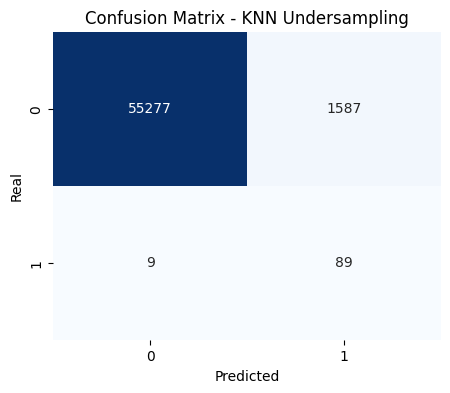

In [48]:
param_grid_knn = {'model__n_neighbors': 5}

pipeline_knn_undersampling.set_params(**param_grid_knn)
pipeline_knn_undersampling.fit(X_train, y_train)

y_pred = pipeline_knn_undersampling.predict(X_test)
y_proba = pipeline_knn_undersampling.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - KNN Undersampling")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.1001
Precisão:     0.0529
Recall:       0.9184
ROC AUC:      0.9765


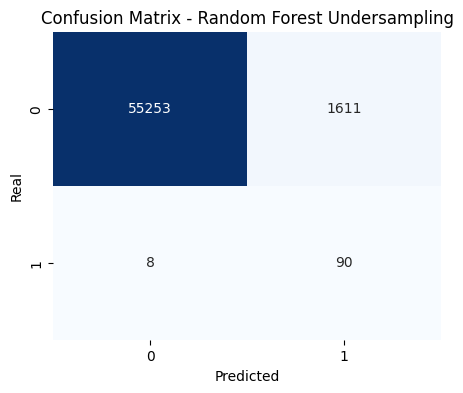

In [46]:
param_grid_rfc = {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}

pipeline_rfc_undersampling.set_params(**param_grid_rfc)
pipeline_rfc_undersampling.fit(X_train, y_train)

y_pred = pipeline_rfc_undersampling.predict(X_test)
y_proba = pipeline_rfc_undersampling.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Random Forest Undersampling")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.0644
Precisão:     0.0334
Recall:       0.9184
ROC AUC:      0.9733


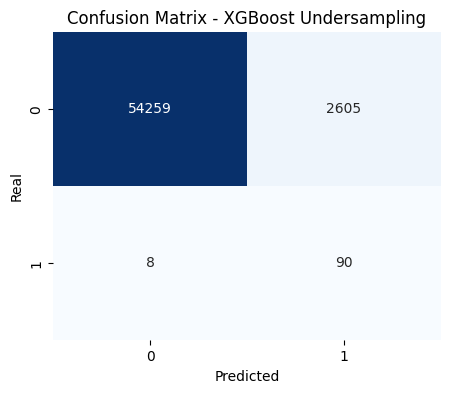

In [45]:
param_grid_xgb = {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}

pipeline_xgb_undersampling.set_params(**param_grid_xgb)
pipeline_xgb_undersampling.fit(X_train, y_train)

y_pred = pipeline_xgb_undersampling.predict(X_test)
y_proba = pipeline_xgb_undersampling.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - XGBoost Undersampling")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.0716
Precisão:     0.0373
Recall:       0.8776
ROC AUC:      0.9588


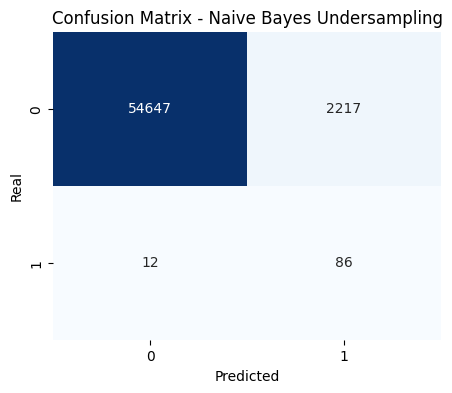

In [50]:
param_grid_nb = {'model__var_smoothing': 1e-06}

pipeline_nb_undersampling.set_params(**param_grid_nb)
pipeline_nb_undersampling.fit(X_train, y_train)

y_pred = pipeline_nb_undersampling.predict(X_test)
y_proba = pipeline_nb_undersampling.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Naive Bayes Undersampling")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.2153
Precisão:     0.1227
Recall:       0.8776
ROC AUC:      0.9752


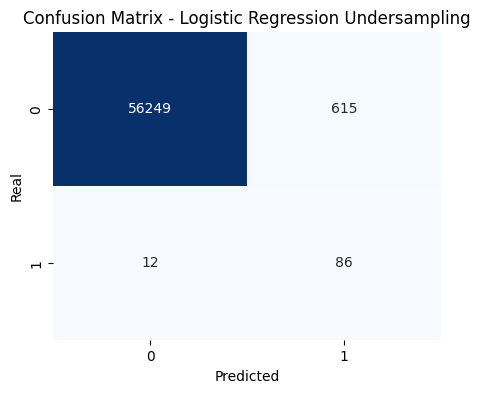

In [51]:
param_grid_lr = {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'saga'}

pipeline_lr_undersampling.set_params(**param_grid_lr)
pipeline_lr_undersampling.fit(X_train, y_train)

y_pred = pipeline_lr_undersampling.predict(X_test)
y_proba = pipeline_lr_undersampling.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Logistic Regression Undersampling")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()